In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from brisque.brisque import BRISQUE

In [132]:
def load_image(path):
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def detect_blue_mask(image, mask_region):
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    
    lower_blue = np.array([90, 50, 50])
    upper_blue = np.array([140, 255, 255])
    
    mask = cv2.inRange(hsv, lower_blue, upper_blue)

    y1, x1, y2, x2 = mask_region
    mask_of_region = np.zeros((y2-y1, x2-x1), dtype=np.uint8)
    mask_of_region = mask[y1:y2, x1:x2]
    return mask_of_region

def inpaint_image(image, mask, method="telea", radius=3):
    if method == "telea":
        flag = cv2.INPAINT_TELEA
    else:
        flag = cv2.INPAINT_NS
        
    return cv2.inpaint(image, mask, radius, flag)

def pipeline(image_path, cuts, out_path):
    image = load_image(image_path)

    y1 = cuts[0]
    x1 = cuts[1]
    y2 = image.shape[0]-cuts[2]
    x2 = image.shape[1]-cuts[3]
    mask_region = (y1, x1, y2, x2)
    mask = detect_blue_mask(image, mask_region)
    image_cut = np.zeros((y2-y1, x2-x1), dtype=np.uint8)
    image_cut = image[y1:y2, x1:x2]
    
    result_telea = inpaint_image(image_cut, mask, method="telea", radius=3)
    result_ns = inpaint_image(image_cut, mask, method="ns", radius=3)

    score_telea = cv2.quality.QualityBRISQUE_compute(result_telea, "brisque_model.yml", "brisque_range.yml")
    score_ns = cv2.quality.QualityBRISQUE_compute(result_ns, "brisque_model.yml", "brisque_range.yml")
    print(f"BRISQUE Score (telea): {score_telea}")
    print(f"BRISQUE Score (ns): {score_ns}")
    
    plt.figure(figsize=(16,12))
    
    plt.subplot(2,2,1)
    plt.title(f"Obraz - {image_path}")
    plt.imshow(image)
    
    plt.subplot(2,2,2)
    plt.title("Maska (niebieskie)")
    plt.imshow(mask, cmap='gray')
    
    plt.subplot(2,2,3)
    plt.title("Inpainting - telea")
    plt.imshow(result_telea)

    plt.subplot(2,2,4)
    plt.title("Inpainting - ns")
    plt.imshow(result_ns)
    
    plt.show()
    
    cv2.imwrite(out_path, cv2.cvtColor(result_ns, cv2.COLOR_RGB2BGR))

BRISQUE Score (telea): (45.31594467163086, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (45.53419876098633, 0.0, 0.0, 0.0)


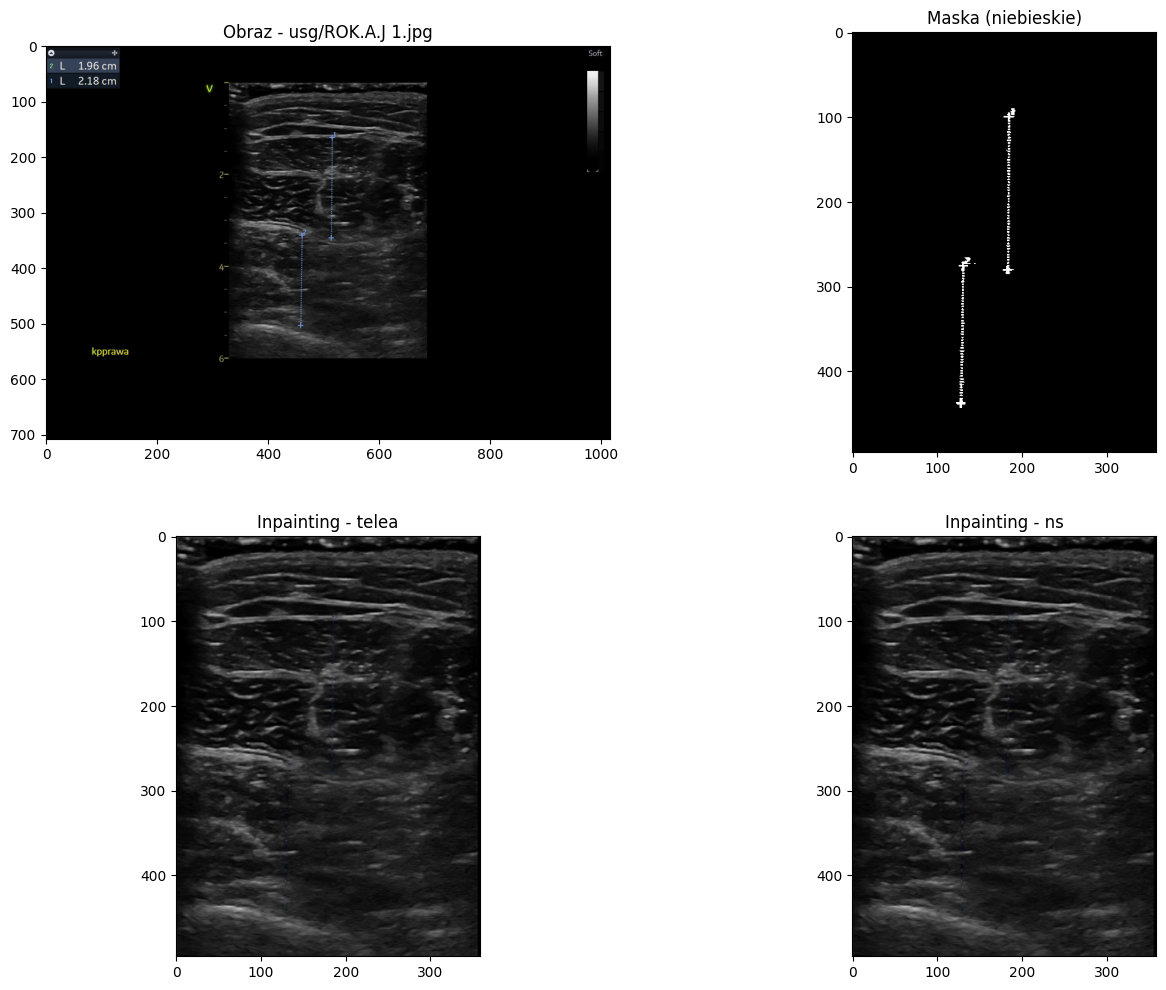

BRISQUE Score (telea): (43.23285675048828, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (43.454559326171875, 0.0, 0.0, 0.0)


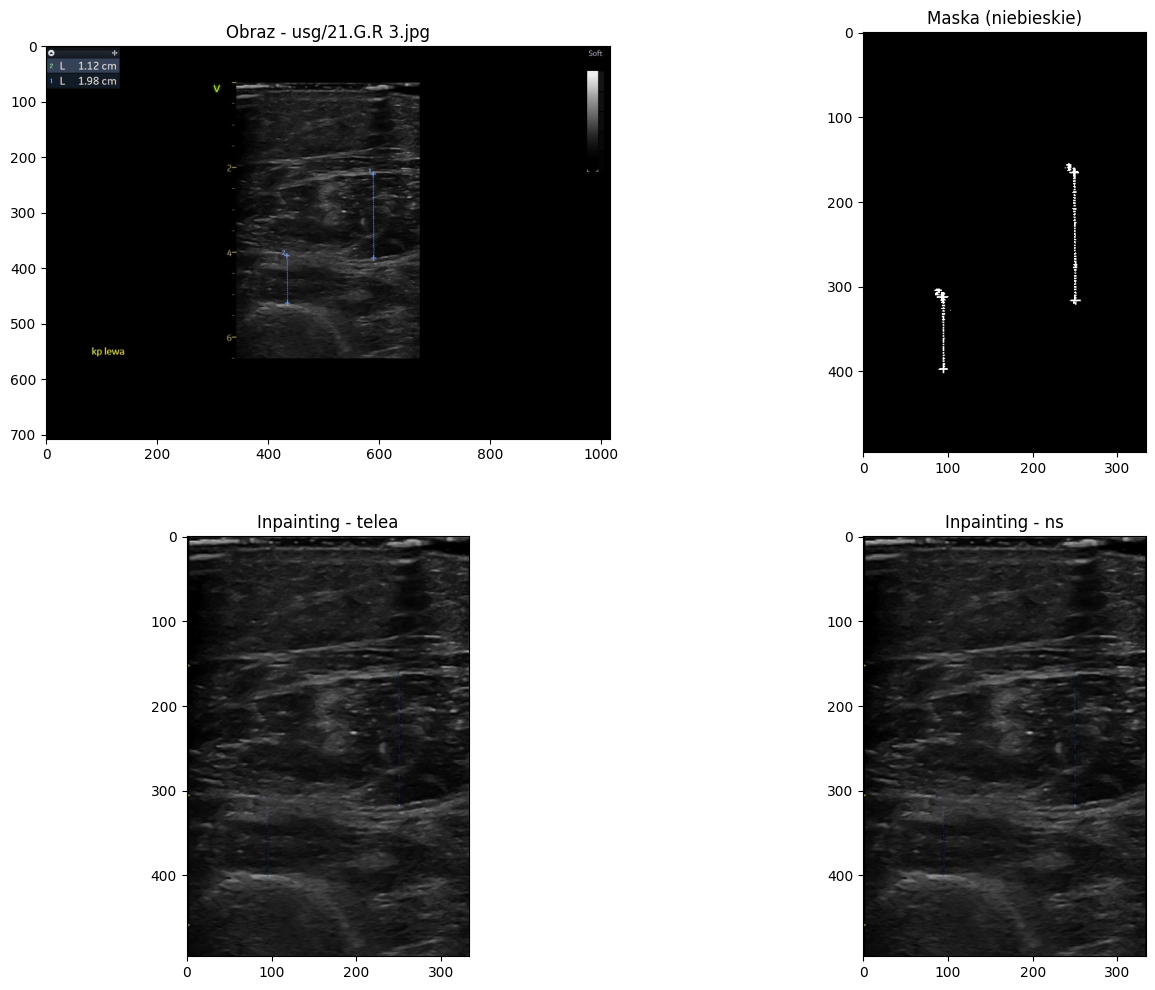

BRISQUE Score (telea): (33.67746353149414, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (33.777645111083984, 0.0, 0.0, 0.0)


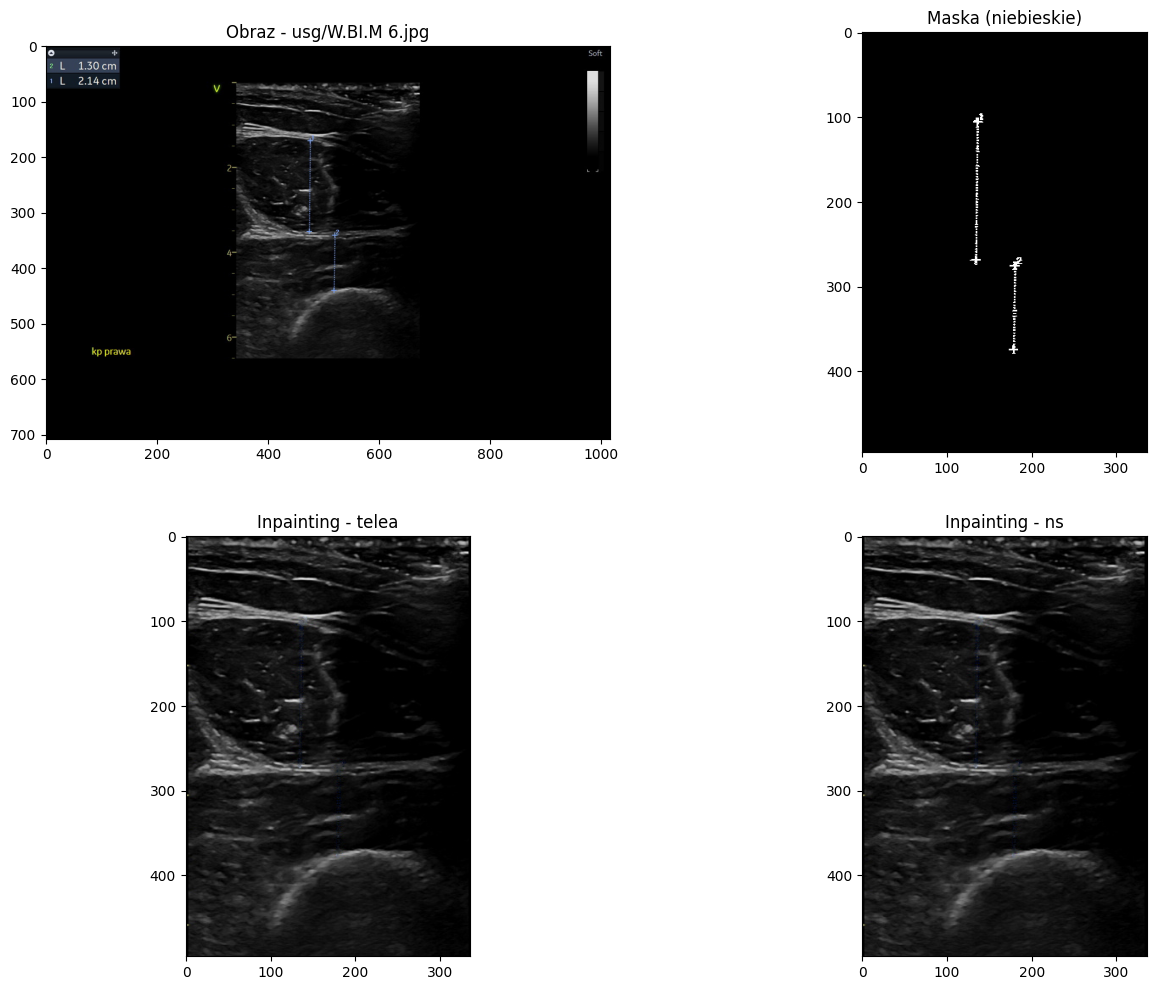

BRISQUE Score (telea): (45.26871871948242, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (45.390228271484375, 0.0, 0.0, 0.0)


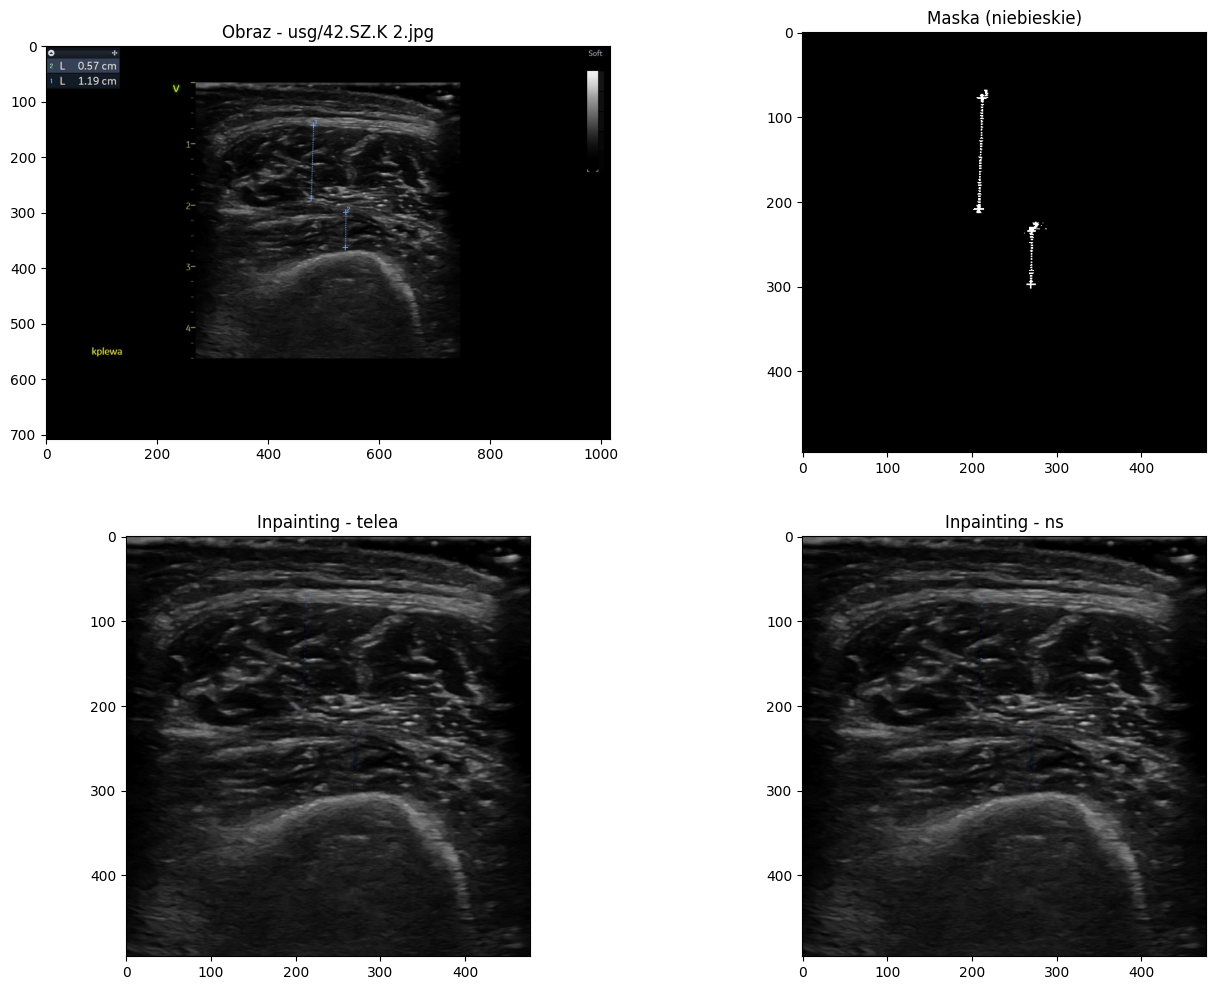

BRISQUE Score (telea): (44.45650863647461, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (44.45458984375, 0.0, 0.0, 0.0)


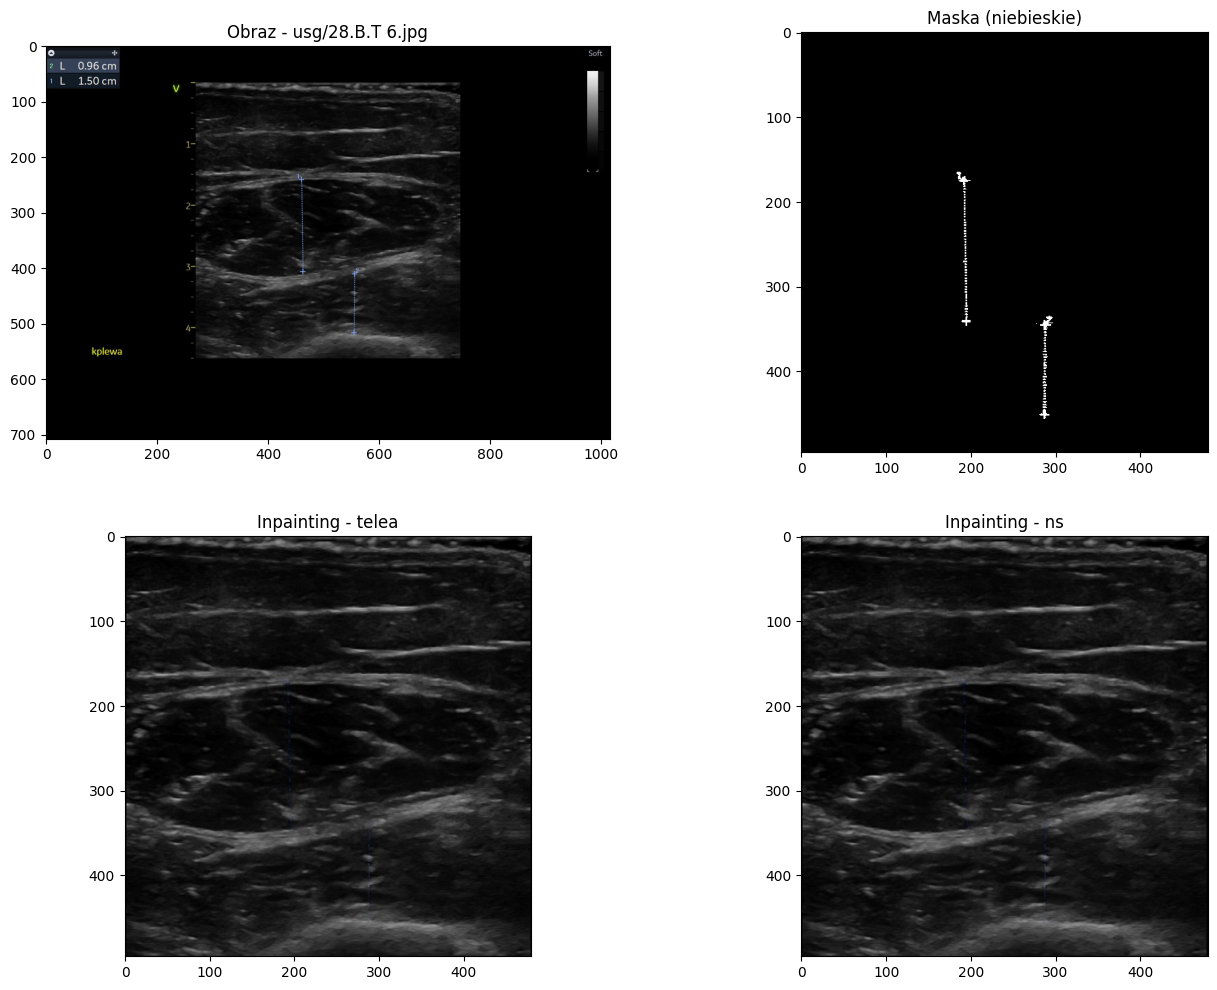

BRISQUE Score (telea): (46.12971115112305, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (46.08877182006836, 0.0, 0.0, 0.0)


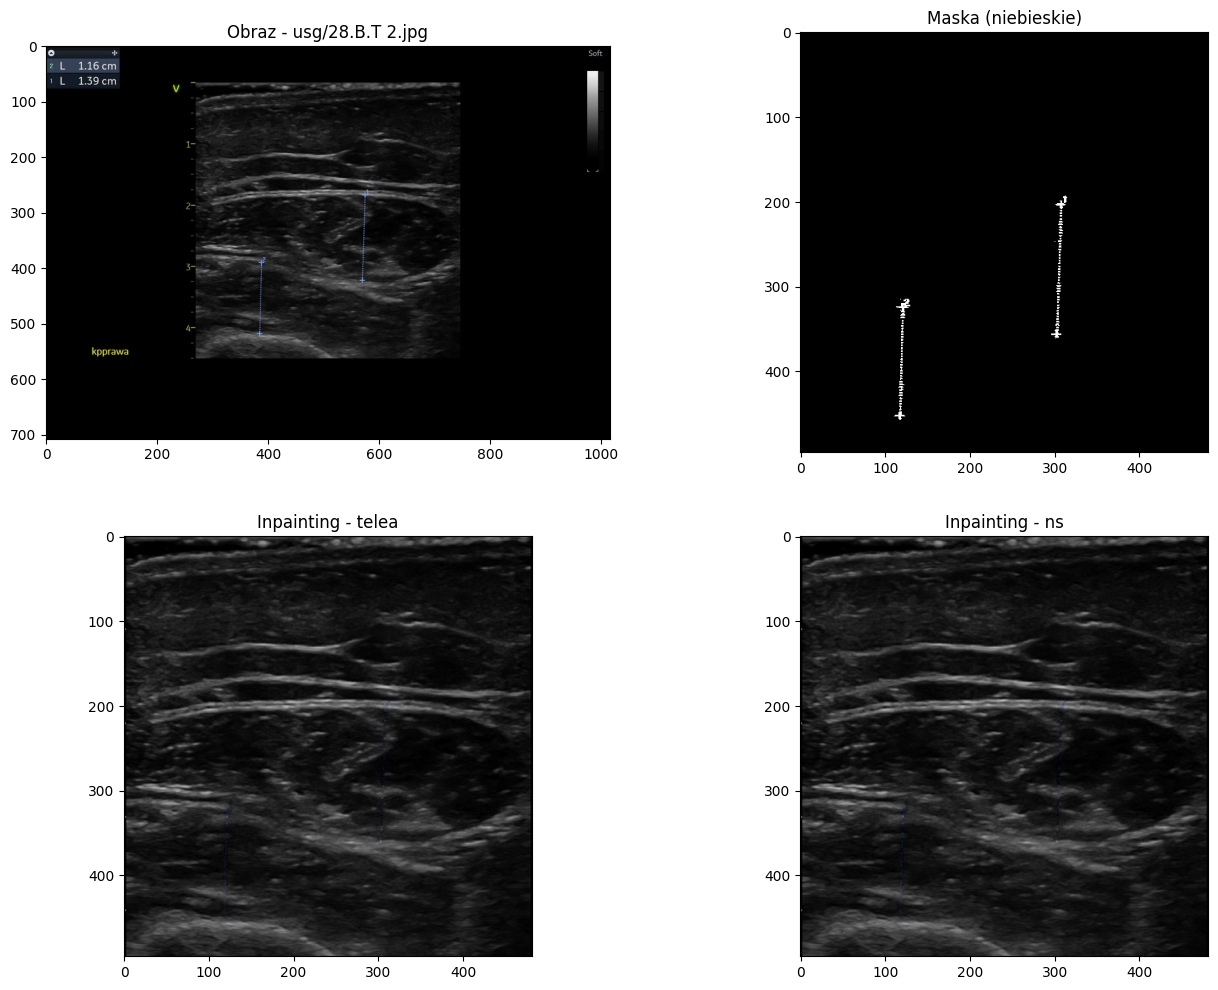

BRISQUE Score (telea): (45.8018684387207, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (45.899681091308594, 0.0, 0.0, 0.0)


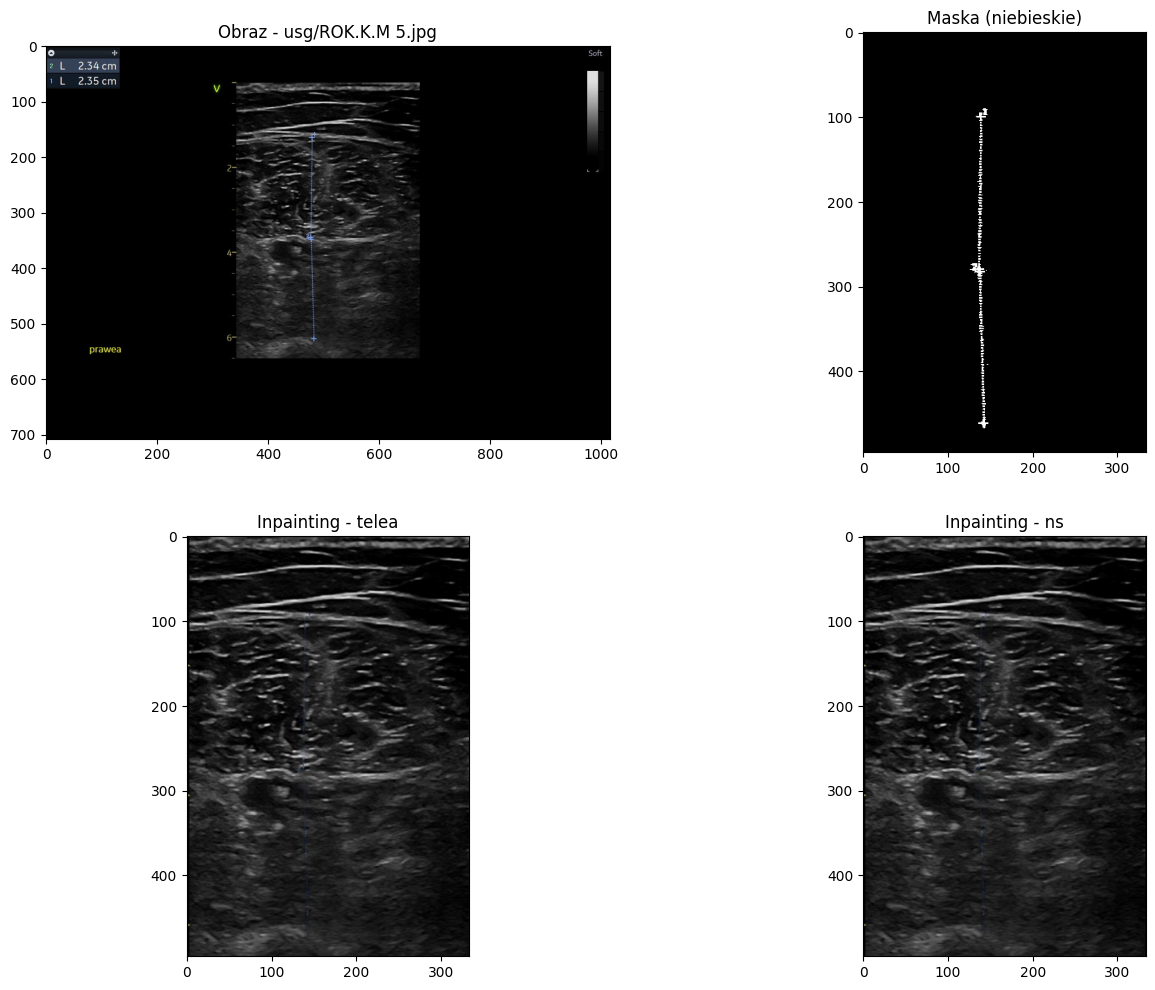

BRISQUE Score (telea): (44.440025329589844, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (44.640113830566406, 0.0, 0.0, 0.0)


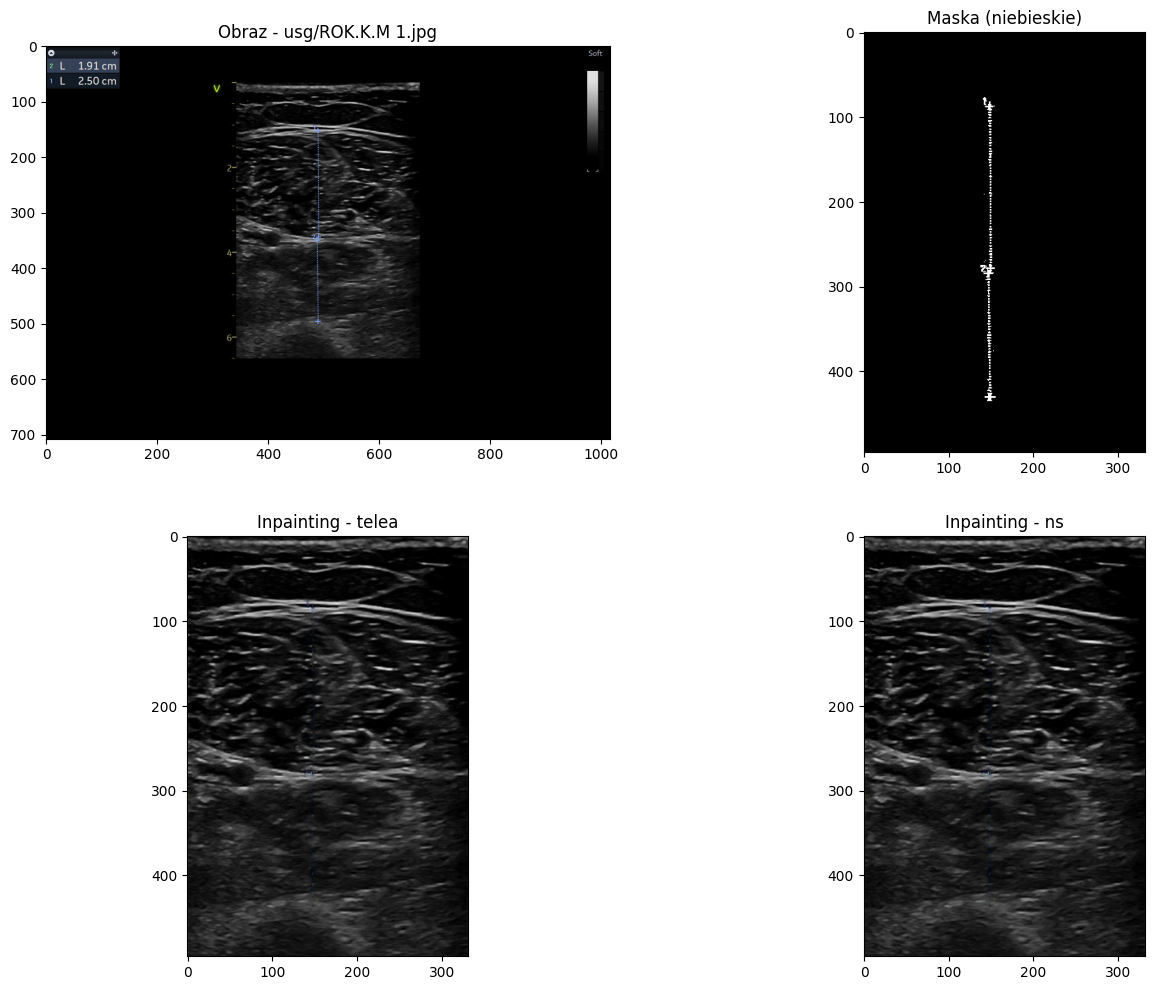

BRISQUE Score (telea): (49.135986328125, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (49.2607307434082, 0.0, 0.0, 0.0)


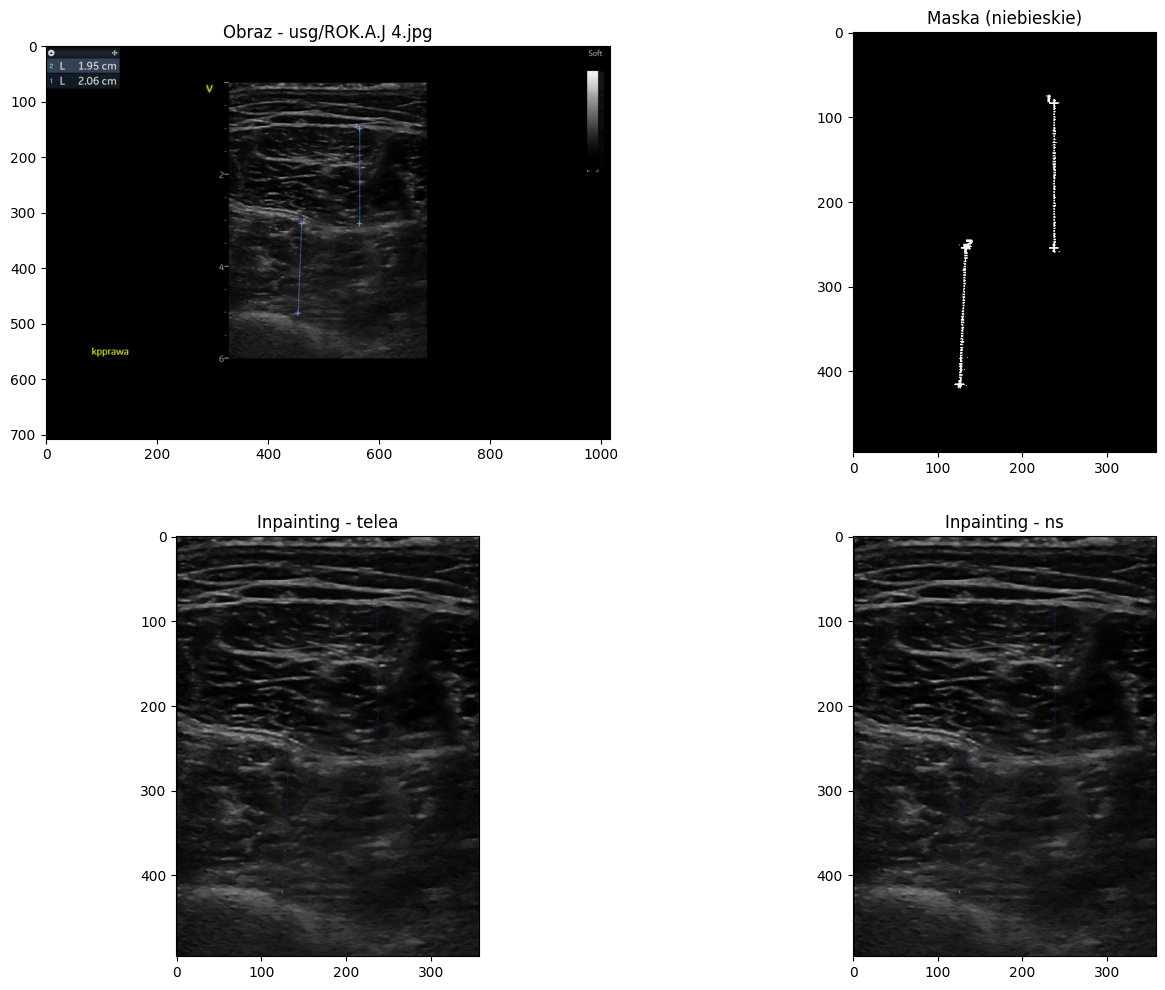

BRISQUE Score (telea): (46.55510330200195, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (46.60670852661133, 0.0, 0.0, 0.0)


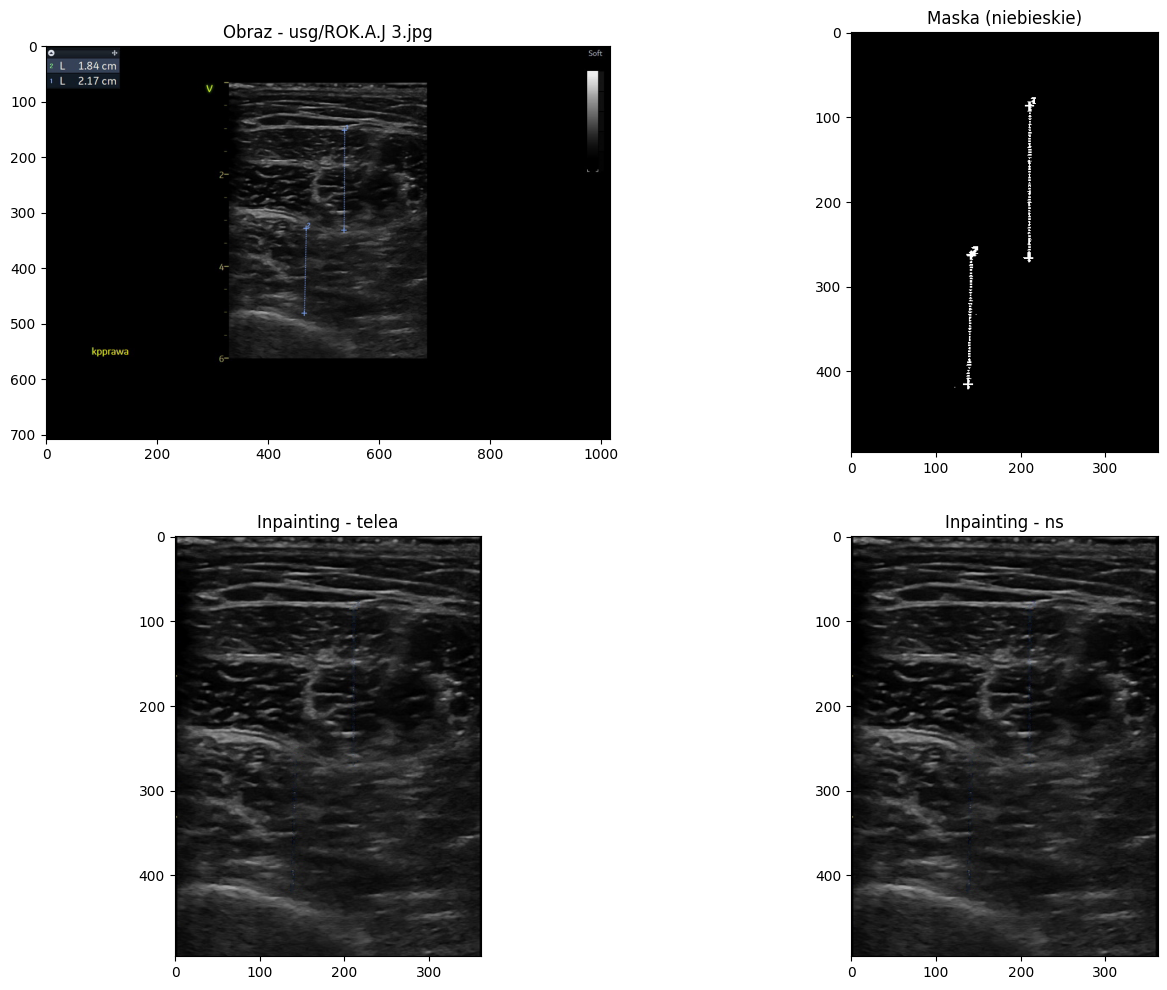

BRISQUE Score (telea): (45.66721725463867, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (45.79043197631836, 0.0, 0.0, 0.0)


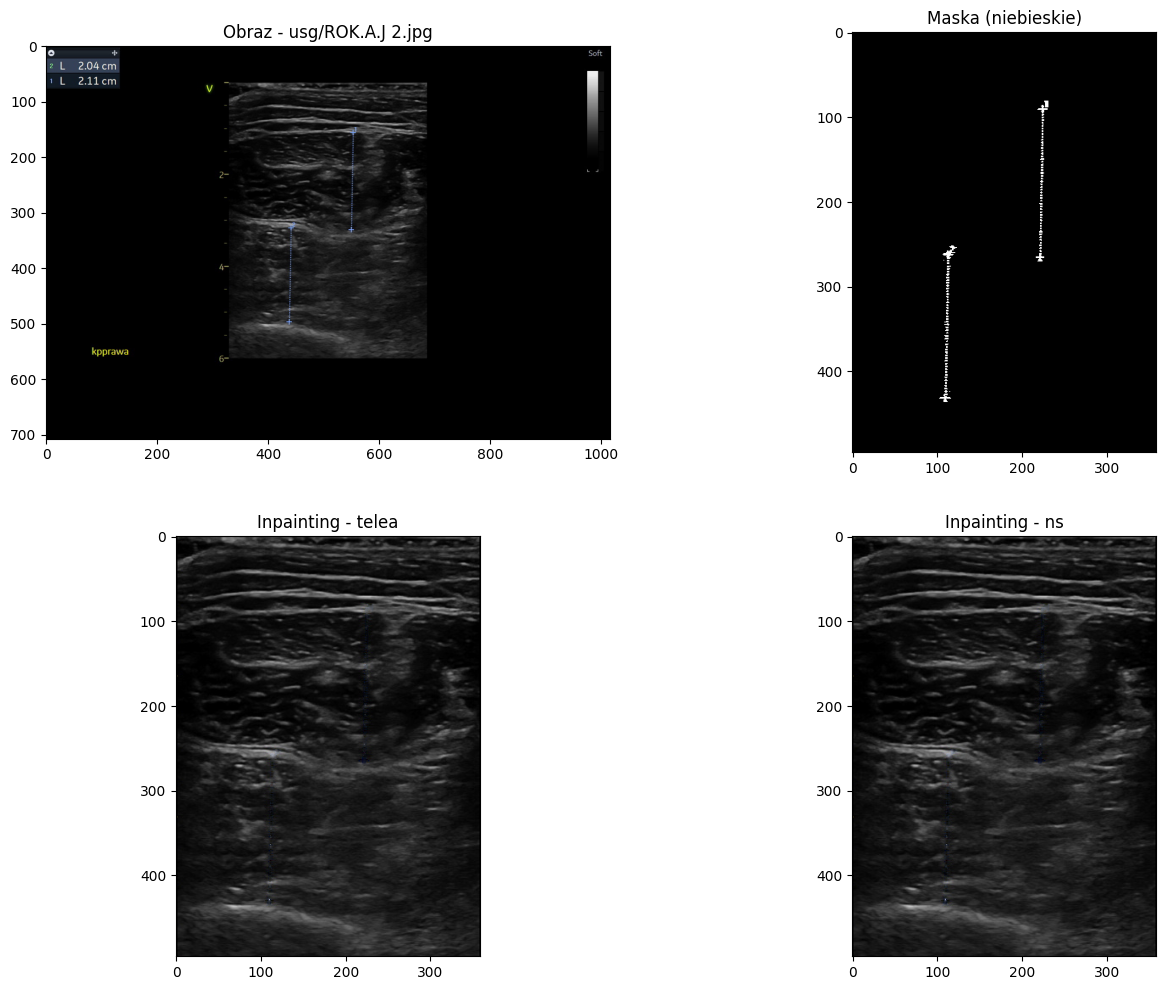

In [134]:
cuts = [
    (65,330,147,327),
    (65,340,147,342),
    (65,340,147,340),
    (65,269,147,270),
    (65,268,147,268),
    (65,267,147,267),
    (65,340,147,342),
    (65,342,147,342),
    (65,328,147,330),
    (65,327,147,327),
    (65,328,147,329)
]
cut_id = 0
dir_path = "usg"
out_dir = "usg-out"
for file in os.listdir(dir_path):
    if file.endswith(".jpg"):
        path = os.path.join(dir_path, file)
        out_path = os.path.join(out_dir, file)
        pipeline(path, cuts[cut_id], out_path)
        cut_id += 1